<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [3]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Reading FoodHub order transaction history data set from google drive.
# Mounting and loading the order data in Panda DataFrame for further analytics

df = pd.read_csv("/content/drive/MyDrive/AIML-UTA-PY/foodhub_order.csv")

In [6]:
# Displaying the first 20 rows of the DataFrame
# This helps in validating that the data has been loaded correctly
# and provides an initial view of the data structure, format, schema and quality
# to help in the data analysis.
# Default is 5 rows, however, here I am displaying 20 rows

df.head(20)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30
8,1477174,121706,Anjappar Chettinad,Indian,16.44,Weekday,5,21,26
9,1477311,39705,Bukhara Grill,Indian,7.18,Weekday,5,29,26


#### **Observations**
1. The dataset structure aligns well with the provided data dictionary, with all 20 columns present as expected.
2. Each row represents a unique food order, and order_id appears to act as a primary/unique identifier.
3. The dataset includes a mix of categorical variables (e.g., restaurant_name, cuisine_type, day_of_the_week) and numerical/decimal variables (e.g., cost_of_the_order, food_preparation_time, delivery_time).
4. The rating column contains both numerical values and text entries (e.g., “Not given”), indicating that special handling will be required before performing any numerical or mathematical analysis on this column.
5. Some restaurant names include Unicode characters (e.g., Chinese/Mandarin, observed in order_id 1477895), which indicates multilingual support and may require attention during text-based operations.
6. The data is indexed sequentially (0 to n), which is the default structure of a Pandas DataFrame.
7. Assuming the cost unit or currency is dollar ($) and refer it accordingly goring forward.


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [9]:
# Inspect the share of the dataset (rows, columns)
df.shape

(1898, 9)

#### Observations:
The dataset contains **1898** rows and **9** columns. This also mean total number of orders is 1898 in this dataset.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [10]:
# Using DataFram info funcation inspecting data types, non-null counts, and
# overall structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
1. The dataset does not contain any null or missing values across the columns, indicating that all fields are populated. The Non-Null count matching with number or rows 1898.
2. Columns are integer identifiers order_id, customer_id, food_preparation_time, delivery_time are of integer data type
3. The Column cost_of_the_order is a float or decimal type which contains the cost.
4. Columns restaurant_name, cuisine_type, day_of_the_week are object data type.
5. The rating column is stored as an object data type due to the presence of both numerical values and text entries (e.g., "Not given"), and will require preprocessing before numerical analysis.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [11]:
# Checking for missing values in the dataset
df.isna().sum()


,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
1. There are missing data (null valuee) in the dataset
2. However, the rating column contains the value "Not given" (observed in data validation), is actually representing missing data.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [12]:
# Generating descriptive statistics for numerical columns.
# df.describe() provides:
# - Count of non-missing values
# - Mean (average)
# - Standard deviation (spread of the data)
# - Min and max values
# - Quartiles (25%, 50%, 75%)
# This analysis matter more for 'cost_of_the_order',	'food_preparation_time'
# and	'delivery_time' column as ID columns are unique identifiers.
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
1. The 'order_id' and 'customer_id' columns act as identifiers for each order and customer, respectively, and do not provide meaningful insights for numerical analysis.
2. The cost of an order ranges from 4.47 to 35.41 dollars (assuming dollar is the curency type), with an average order cost around 16 dollars and a standard deviation of 7.5 dollars.
3. The cost of 75% of the orders are below 23 dollars. This indicates that most of the customers prefer low-cost food compared to the expensive ones.
4. Food preparation time ranges from 20 to 35 minutes, with an average of around 27 minutes and a standard deviation of 4.6 minutes. The spread is not very high for the food preparation time.
5. Delivery time ranges from 15 to 33 minutes, with an average of around 24 minutes and a standard deviation of 5 minutes. The spread is not too high for delivery time either.

In [13]:
# Generate descriptive statistics for ALL columns (numeric + non-numeric)
# include='all' forces pandas to summarize:
# - Numeric columns (mean, std, min, quartiles, max)
# - Categorical columns (unique count, top value, frequency)
# - Boolean columns
# - Datetime columns (count, unique, min, max)
#
# .T transposes the output:
# - Rows become columns
# - Columns become rows

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:
1. The average order cost is approx 16.50 dollar, while the average food preparation time is around 27 minutes and the average delivery time is approximately 24 minutes.
2. 75th percentile shows that 75% of orders cost less than $22.30, indicating that most customers prefer moderately or low priced meals.
3. Food preparation time ranges from 20 minutes to 35 minutes, with an average of approximately 27 minutes, also with 75% of orders being prepared within 31 minutes, suggesting relatively consistent kitchen performance.
4. Delivery time ranges from 15 minutes to 33 minutes, with 75% of deliveries completed within 28 minutes, indicating stable delivery operations.
5. The standard deviation for cost (aprox 7.5) is relatively higher compared to preparation and delivery times (aprox 4.6 and 5 respectively), indicating greater variability in customer spending than in operational timings.
6. The variation in preparation and delivery times suggests that while most orders follow a consistent timeline, some orders take longer, which may impact customer experience.


In [14]:
# Calculate key statistics for food preparation time
# ---------------------------------------------------
# min()  -> shortest preparation time in the dataset
# mean() -> average preparation time across all orders
# max()  -> longest preparation time recorded
#
# These metrics help you understand:
# - Operational efficiency
# - Variability in kitchen performance
# - Potential bottlenecks in food preparation
food_prep_min = df['food_preparation_time'].min()
food_prep_mean = df['food_preparation_time'].mean()
food_prep_max = df['food_preparation_time'].max()
food_prep_min, food_prep_mean, food_prep_max

(20, np.float64(27.371970495258168), 35)

#### Observations:
1. The food preparation time ranges from 20 to 35 minutes, with an average of approximately 27 minutes, indicating generally consistent kitchen performance with moderate variation across orders.

### **Question 5:** How many orders are not rated? [1 mark]

In [19]:
# Get the total number of orders in the dataset
order_length = len(df)
print('Total Order Count:', order_length)
print()
# Filter the dataframe to include only rows where the rating is "Not given"
# Then count how many such orders exist
print("Rating     Count     %")
print("---------- --------- -----")
orders_without_rating = df[df['rating'] == 'Not given']['rating'].count()
print('Not Given  ' + str(orders_without_rating) + '       ' + f"{(orders_without_rating * 100 / order_length):.2f}" )
orders_with_rating_1 = df[df['rating'] == '1']['rating'].count()
print('1          ' + str(orders_with_rating_1) + '         ' + f"{(orders_with_rating_1 * 100 / order_length):.2f}" )
orders_with_rating_2 = df[df['rating'] == '2']['rating'].count()
print('2          ' + str(orders_with_rating_2) + '         ' + f"{(orders_with_rating_2 * 100 / order_length):.2f}" )
orders_with_rating_3 = df[df['rating'] == '3']['rating'].count()
print('3          ' + str(orders_with_rating_3) + '       ' + f"{(orders_with_rating_3 * 100 / order_length):.2f}" )
orders_with_rating_4 = df[df['rating'] == '4']['rating'].count()
print('4          ' + str(orders_with_rating_4) + '       ' + f"{(orders_with_rating_4 * 100 / order_length):.2f}" )
orders_with_rating_5 = df[df['rating'] == '5']['rating'].count()
print('5          ' + str(orders_with_rating_5) + '       ' + f"{(orders_with_rating_5 * 100 / order_length):.2f}" )
print("--------------------------")


Total Order Count: 1898

Rating     Count     %
---------- --------- -----
Not Given  736       38.78
1          0         0.00
2          0         0.00
3          188       9.91
4          386       20.34
5          588       30.98
--------------------------


#### Observations:
1. A significant portion of orders (38.78%) have no rating,
2. Among the rated orders, most customers have given high ratings (4 and 5), indicating generally positive customer satisfaction.
3. Over 50% or ratings are 4 and 5
4. No customer gave rating 1 or 2

### Exploratory Data Analysis (EDA)

### Univariate Analysis

**Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

1. **Order Cost Distribution** *cost_of_the_order*

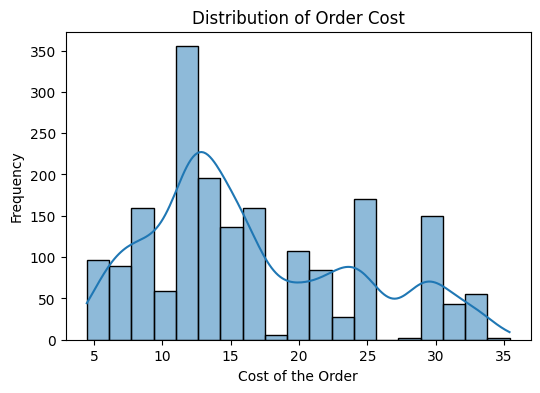

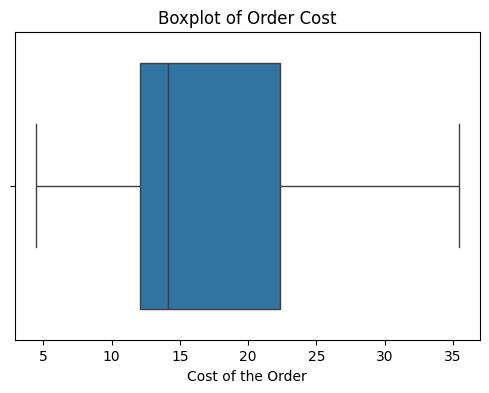

In [20]:
# Visualizing the distribution of order cost
# Histogram helps understand the distribution and skewness
# Boxplot helps identify spread and potential outliers

plt.figure(figsize=(6,4))
sns.histplot(df['cost_of_the_order'], kde=True)
plt.title('Distribution of Order Cost')
plt.xlabel('Cost of the Order')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['cost_of_the_order'])
plt.title('Boxplot of Order Cost')
plt.xlabel('Cost of the Order')
plt.show()

**Observations**
1. Most orders are concentrated in the lower to mid price range (aprox 10 to 25).
2. The distribution is slightly right-skewed, indicating fewer high-value orders.
3. A few higher-cost orders are visible, suggesting potential outliers.
4. This indicates that customers generally prefer affordable meals.

2. **Food Preparation Time** *food_preparation_time*



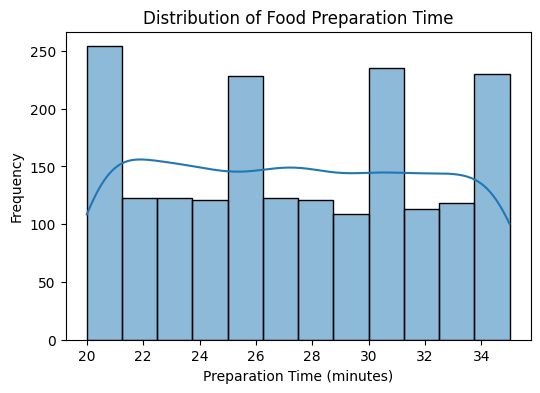

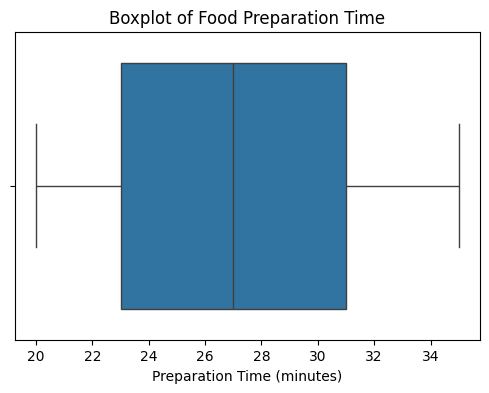

In [21]:
# Visualizing food preparation time distribution
# Helps assess consistency and variability in kitchen operations

plt.figure(figsize=(6,4))
sns.histplot(df['food_preparation_time'], kde=True)
plt.title('Distribution of Food Preparation Time')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['food_preparation_time'])
plt.title('Boxplot of Food Preparation Time')
plt.xlabel('Preparation Time (minutes)')
plt.show()

**Observation**
1. Food preparation time is centered around 25 to 30 minutes.
2. The distribution appears fairly normal with limited skewness.
3. The spread is narrow, indicating consistency in preparation time.
4. Very few extreme values are observed, suggesting stable kitchen performance.

3. **Delivery Time** *delivery_time*

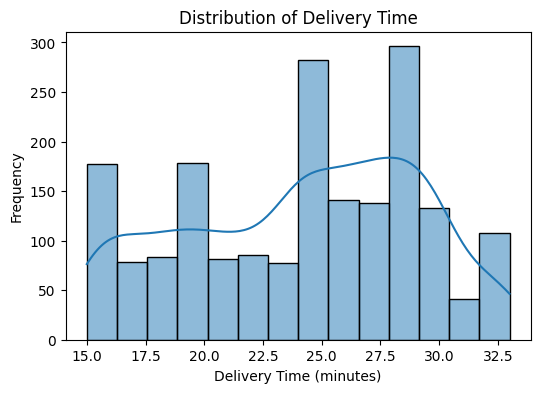

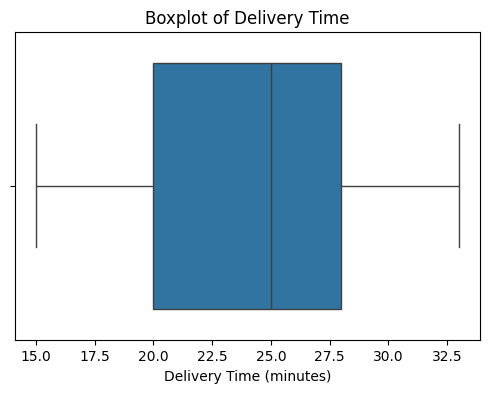

In [22]:
# Visualizing delivery time distribution
# Helps understand delivery performance and variability

plt.figure(figsize=(6,4))
sns.histplot(df['delivery_time'], kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['delivery_time'])
plt.title('Boxplot of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.show()

**Observations**
1. Delivery times are mostly concentrated between 20 to 30 minutes.
2. The distribution is relatively symmetric with slight variation.
3. The spread is moderate, indicating consistent delivery performance.
4. A few higher delivery times may be due to external factors like traffic or distance.

4. **Cuisine Type Distribution** *cuisine_type*

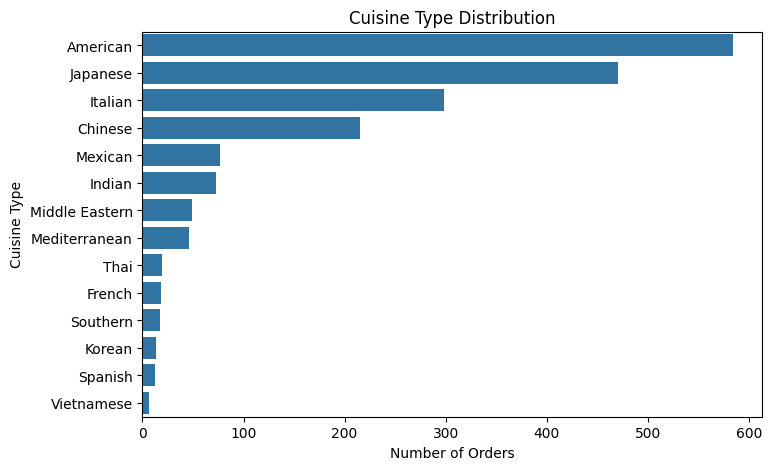

In [23]:
# Countplot to analyze frequency of different cuisine types
# Helps identify most popular cuisines

plt.figure(figsize=(8,5))
sns.countplot(data=df, y='cuisine_type', order=df['cuisine_type'].value_counts().index)
plt.title('Cuisine Type Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Cuisine Type')
plt.show()

**Observations**
1. few cuisine types dominate the dataset.
3. American cuisine appears to be the most frequently ordered.
4. There is a long tail of less frequently ordered cuisines.
5. This indicates that customer demand is concentrated around specific cuisine types.

5. **Restaurant Distribution** (Top 15) *restaurant_name*

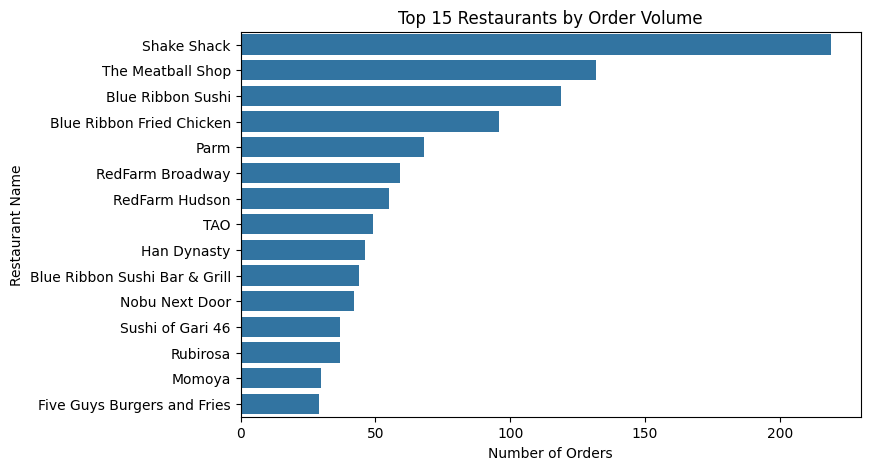

In [29]:
# Identifying top 15 restaurants based on order count
# Helps understand demand concentration across restaurants

top_restaurants = df['restaurant_name'].value_counts().head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title('Top 15 Restaurants by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.show()

**Observations**
1. A small number of restaurants receive a high volume of orders.
2. Demand is concentrated among top-performing restaurants.
3. Popular restaurants play a key role in driving platform engagement.
4. There is a significant drop in order volume after top restaurants.

6. **Day of the Week** *day_of_the_week*

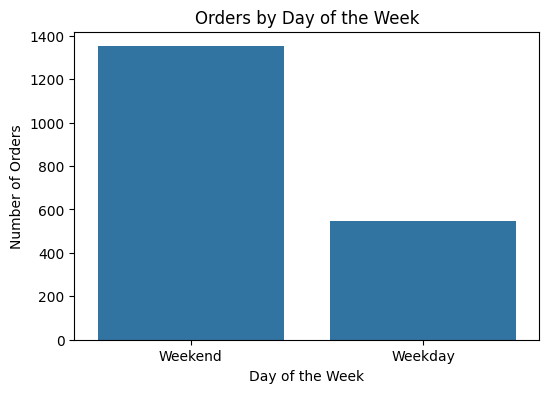

In [26]:
# Analyzing order distribution by day of the week
# Helps understand customer ordering patterns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='day_of_the_week')
plt.title('Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

**Observations**
1. Orders are significantly higher on weekends compared to weekdays.
2. This suggests increased customer activity during weekends.
3. Likely driven by leisure time and reduced work commitments.
4. Weekday demand is comparatively lower and more stable.

7. **Rating Distribution** *rating*

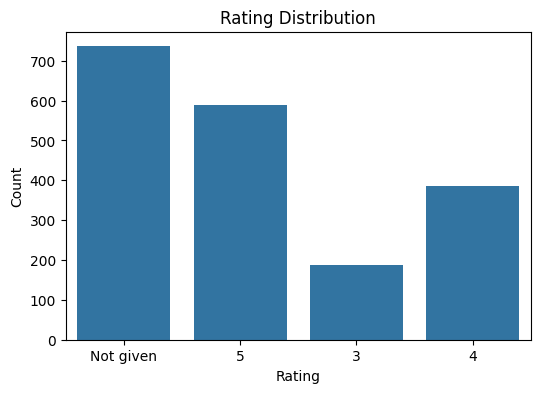

In [27]:
# Visualizing rating distribution
# Includes both given ratings and 'Not given' values

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='rating')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Observations**
1. A large proportion of orders have no rating ("Not given").
2. Among the rated orders, ratings of 4 and 5 are most frequent.
3. Very few low ratings (1 or 2) are observed.
4. This indicates generally high customer satisfaction.

### **Concluding Observation**
Overall, the univariate analysis indicates that customer orders:
1. Concentrated in lower to mid price ranges,
2. Operational metrics such as preparation and delivery times are consistent,
3. Customer satisfaction is generally high.
4. Demand is also concentrated among specific cuisines and top-performing restaurants,
5. While higher activity observed during weekends.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [38]:
# Identifying top 5 restaurants based on number of orders received
top_5_restaurants = df['restaurant_name'].value_counts().head(5)

top_5_restaurants.reset_index()

,restaurant_name,count
0,Shake Shack,219
1,The Meatball Shop,132
2,Blue Ribbon Sushi,119
3,Blue Ribbon Fried Chicken,96
4,Parm,68


#### Observations:
The top 5 restaurants in terms of number of orders received are:
* Restaurant 1: Shake Shack
* Restaurant 2: The Meatball Shop
* Restaurant 3: Blue Ribbon Sushi
* Restaurant 4: Blue Ribbon Fried Chicken
* Restaurant 5: Parm

These are key partners for FoodHub and likely drive a large portion of revenue and customer engagement.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [41]:
# Filtering data for weekend orders
weekend_orders = df[df['day_of_the_week'] == 'Weekend']

# Finding the most popular cuisine on weekends
most_popular_cuisine = weekend_orders['cuisine_type'].value_counts().idxmax()

weekend_orders['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


#### Observations:
The most popular cuisine on weekends is **American**, followed by other cuisines such as Japanese and Italian, indicating strong customer preference for this cuisine during weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [48]:
# Calculating percentage of orders costing more than $20

total_orders = len(df)

orders_above_20 = df[df['cost_of_the_order'] > 20].shape[0]
total_orders_above_20 = (df['cost_of_the_order'] > 20).sum()

percentage = (orders_above_20 / total_orders) * 100

print(f"Total ordes count:           {total_orders}")
print(f"Orders above $20 count:      {orders_above_20}")
print(f"Orders above $20 Percentage: {round(percentage, 2)}")

Total ordes count:           1898
Orders above $20 count:      555
Orders above $20 Percentage: 29.24


#### Observations:
Approx 29.24% of the orders cost more than $20, suggesting that most customers prefer lower to mid-range priced meals.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [54]:
# Calculating the average delivery time
mean_delivery_time = df['delivery_time'].mean()

#round(mean_delivery_time, 2)
print(f"Mean order delivery time: {round(mean_delivery_time, 2)}")

Mean order delivery time: 24.16


#### Observations:
1. The mean delivery time is aprox 24.16 min, reflecting consistent delivery performance across orders.
2. This gives a baseline SLA, hence, orders significantly above this may feel “slow” to customers.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [56]:
# Identifying top 3 customers based on number of orders placed
top_customers = df['customer_id'].value_counts().head(3)

# Converting to DataFrame for clarity
top_customers_df = top_customers.reset_index()
top_customers_df.columns = ['customer_id', 'number_of_orders']

top_customers_df

,customer_id,number_of_orders
0,52832,13
1,47440,10
2,83287,9


#### Observations:
The top 3 most frequent customers are:
1. Customer ID 52832 with 13 orders - The most loyal user.
2. Customer ID 47440 with 10 orders
3. Customer ID 83287 with 9 orders

These customers have placed the highest number of orders and can be rewarded with discount or referal vouchers to encourage continued engagement.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


1. **Correlation between Numerical Variables** (cost_of_the_order, food_preparation_time, delivery_time)

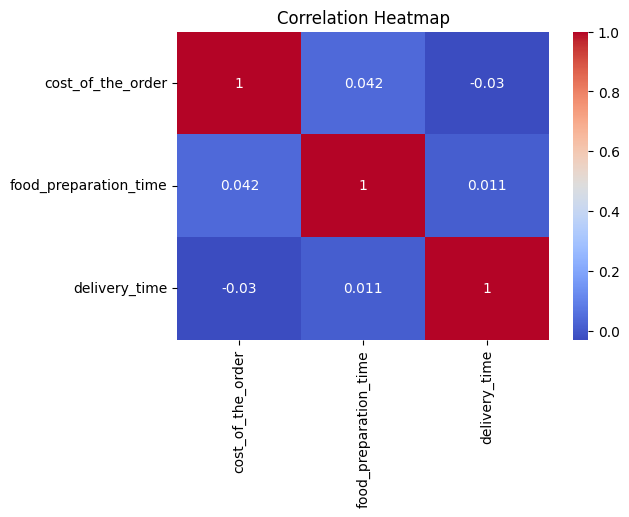

In [57]:
# Analyzing correlation between numerical variables
# Helps identify relationships between time and cost variables

num_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observations**
1. The correlation values between numerical variables (cost, delivery and food preparation time) are very close to zero, indicating no strong linear relationship between them.
2. The correlation between cost_of_the_order and food_preparation_time (aprox 0.04) is negligible, suggesting that order cost does not impact preparation time.
3. The correlation between cost_of_the_order and delivery_time (aprox -0.03) is slightly negative but insignificant, indicating no meaningful relationship.
4. The correlation between food_preparation_time and delivery_time (aprox 0.01) is also extremely weak, showing that these two operational processes are largely independent.
5. Overall, all numerical variables appear to operate independently, with no strong dependencies observed.
6. This also suggests that operational efficiency (time-related metrics) and pricing are managed independently across orders.

2. **Cost vs Cuisine Type**

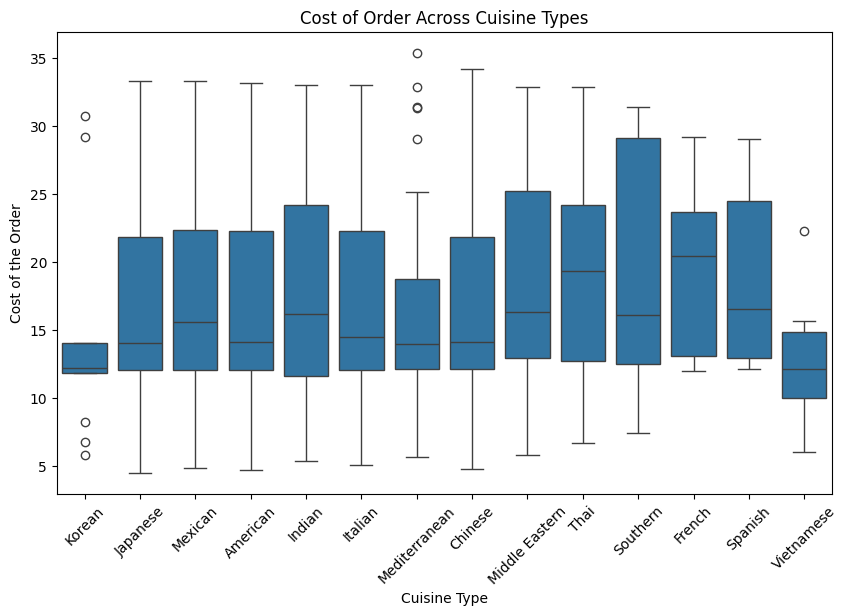

In [60]:
# Comparing order cost across cuisine types
# Helps identify expensive and budget-friendly cuisines

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=45)
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.title('Cost of Order Across Cuisine Types')
plt.show()

**Observations**
1. There is noticeable variation in order cost across different cuisine types.
2. French, Southern, and Thai cuisines tend to have higher median order costs compared to others.
3. Vietnamese cuisine appears to have the lowest median cost, indicating it is relatively more affordable.
4. Some cuisines such as Indian, Mexican, and Middle Eastern show a wider spread, suggesting variability in pricing within those cuisines.
5. Several cuisines exhibit outliers on the higher end, indicating occasional high-value orders.
6. Overall, pricing differs significantly by cuisine type, reflecting differences in menu offerings and customer preferences.
7. Furthermore, this also suggests that certain cuisines are positioned as premium offerings, while others cater to more budget-conscious customers.

3. **Cost vs Day of the Week**

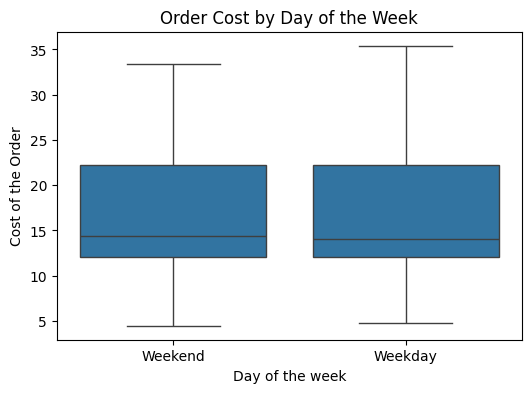

In [11]:
# Comparing order cost between weekday and weekend
# Helps understand spending behavior patterns

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order')
plt.title('Order Cost by Day of the Week')
plt.xlabel('Day of the week')
plt.ylabel('Cost of the Order')
plt.show()

**Observations**
1. The median order cost is very similar for both weekdays and weekends, indicating no significant difference in spending behaviour.
2. The interquartile range (IQR) is also comparable across both categories, suggesting similar variability in order cost.
3. Both weekday and weekend orders show a similar spread, with overlapping distributions.
4. A few higher-value orders are present in both categories, but no clear pattern of higher spending on weekends is observed.
5. Overall, customer spending behaviour appears consistent across weekdays and weekends.
6. Furthermore, this also suggests that customer ordering behaviour in terms of spending is stable throughout the week.

4. **Rating vs Cuisine Type**

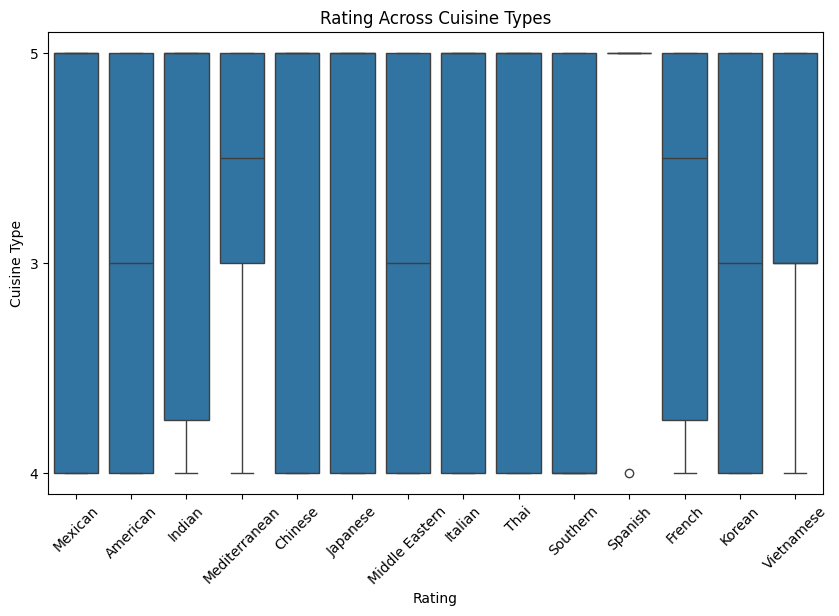

In [12]:
# Analyzing ratings across cuisine types
# Helps identify high-performing cuisines in terms of customer satisfaction

# First remove missing ratings 'Not Given' before analysis
restaurants_not_rated_df = df[df['rating'] != 'Not given'].copy()

plt.figure(figsize=(10,6))
sns.boxplot(data=restaurants_not_rated_df, x='cuisine_type', y='rating')
plt.xticks(rotation=45)
plt.title('Rating Across Cuisine Types')
plt.xlabel('Rating')
plt.ylabel('Cuisine Type')
plt.show()

**Observations**
1. Ratings across all cuisine types are generally high, with most values concentrated between 4 and 5, indicating strong overall customer satisfaction.
2. The median ratings for most cuisines are very similar, suggesting consistent service quality across cuisines.
3. There is limited variability in ratings, with narrow interquartile ranges for most cuisines.
4. Some cuisines such as Mediterranean and French show slightly higher median ratings compared to others.
5. Lower ratings are relatively rare across all cuisines, with only a few isolated cases.
6. Overall, cuisine type does not significantly impact customer ratings, as satisfaction remains uniformly high.
7. Furthermore, this also indicates that FoodHub maintains consistent service quality across different cuisine offerings.

5. **Rating vs Cost of Order**

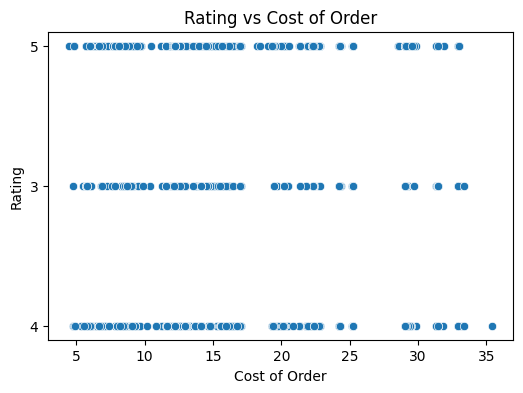

In [15]:
# Checking relationship between cost and rating
# Helps understand if expensive orders lead to better ratings

# Using cleaned dataset (exclude 'Not given')
rating_df = df[df['rating'] != 'Not given'].copy()

plt.figure(figsize=(6,4))
sns.scatterplot(data=rating_df, x='cost_of_the_order', y='rating')
plt.title('Rating vs Cost of Order')
plt.xlabel('Cost of Order')
plt.ylabel('Rating')
plt.show()

**Observations**
1. There is no clear relationship between order cost and customer rating.
2. Ratings are consistently high (mostly between 4 and 5) across all price ranges.
3. Both low-cost and high-cost orders receive similar ratings, indicating that price does not significantly influence customer satisfaction.
4. The data points are widely scattered without any visible trend or pattern.
5. Overall, customer satisfaction appears to be independent of order cost.
6. Furthermore, this also suggests that factors other than price, such as food quality or delivery experience, may have a greater impact on customer satisfaction.

6. **Food Preparation Time vs Delivery Time**

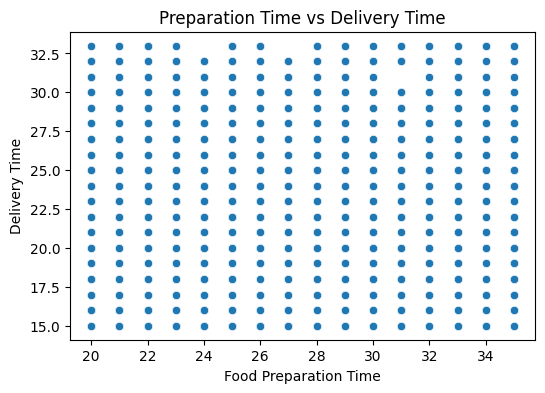

In [17]:
# Exploring relationship between preparation time and delivery time
# Helps assess operational dependency

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='food_preparation_time', y='delivery_time')
plt.title('Preparation Time vs Delivery Time')
plt.xlabel('Food Preparation Time')
plt.ylabel('Delivery Time')
plt.show()

**Observations**
1. There is no clear linear relationship between food preparation time and delivery time.
2. The data points are evenly scattered, indicating that delivery time does not depend on preparation time.
3. Orders with both low and high preparation times show a similar range of delivery times.
4. This suggests that kitchen operations and delivery processes function independently.
5. The consistency in delivery time across varying preparation times indicates stable delivery performance.
6. Furthermore, this also indicates that delays in food preparation do not significantly impact delivery efficiency.

####  Observation Summary of Multivariate Analysis

1. There is no strong correlation between numerical variables such as cost, preparation time, and delivery time, indicating independent operations.
2. Order cost varies across cuisines, with some cuisines positioned as relatively premium, but spending remains consistent across weekdays and weekends.
3. Customer ratings are consistently high across all cuisines and price ranges, showing strong overall satisfaction.
4. No clear relationship is observed between cost and rating, suggesting that higher prices do not guarantee better customer experience.
5. Food preparation time and delivery time operate independently, indicating efficient and well-managed processes.



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [22]:
# Clean rating column
rating_df = df[df['rating'] != 'Not given'].copy()
rating_df['rating'] = pd.to_numeric(rating_df['rating'])

# Aggregate
restaurant_summary = rating_df.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Apply conditions
eligible_restaurants = restaurant_summary[
    (restaurant_summary['rating_count'] > 50) &
    (restaurant_summary['avg_rating'] > 4)
]

#eligible_restaurants
eligible_restaurants.sort_values(by='avg_rating', ascending=False)

,restaurant_name,rating_count,avg_rating
132,The Meatball Shop,84,4.511905
16,Blue Ribbon Fried Chicken,64,4.328125
117,Shake Shack,133,4.278195
17,Blue Ribbon Sushi,73,4.219178


####  Observations
1. The restaurants that meet the promotional criteria (more than 50 ratings and an average rating greater than 4) are listed above.
2. These restaurants demonstrate both high customer engagement and strong customer satisfaction, making them ideal candidates for promotional offers.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [31]:
# Using numpy for vectorized calculation
import numpy as np

df['revenue'] = np.where(df['cost_of_the_order'] > 20,
                         df['cost_of_the_order'] * 0.25,
                         np.where(df['cost_of_the_order'] > 5,
                                  df['cost_of_the_order'] * 0.15,
                                  0))

# Total revenue
total_revenue = df['revenue'].sum()

print(f"Total Revenue: ${total_revenue}")

Total Revenue: $6166.303


####  Observations
1. The total net revenue generated by the company across all orders is approximately $6166.303.
2. This revenue is calculated based on a tiered commission structure, where higher-value orders contribute more significantly to the overall revenue.
3. Orders above 20 dollar contribute a higher share of revenue due to the increased commission rate.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [35]:
# Calculating total delivery time (preparation + delivery)
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Total number of orders
total_orders = len(df)

# Orders taking more than 60 minutes
orders_above_60 = df[df['total_time'] > 60].shape[0]

# Percentage calculation
percentage = (orders_above_60 / total_orders) * 100

print(f"Orders Taking More Than 60 Minutes: {round(percentage, 2)}%")

Orders Taking More Than 60 Minutes: 10.54%


####  Observations
1. Approx 10.54% of the orders take more than 60 minutes from order placement to delivery.
2. This indicates that only a small proportion of orders experience longer delivery times, suggesting overall efficient operations.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [39]:
# Calculating mean delivery time by day type
mean_delivery = df.groupby('day_of_the_week')['delivery_time'].mean()

round(mean_delivery, 2)


,delivery_time
day_of_the_week,
Weekday,28.34
Weekend,22.47


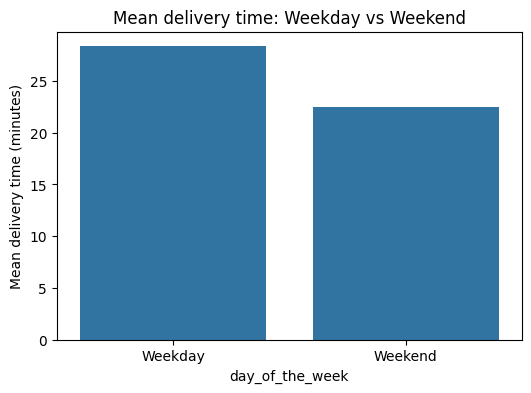

In [41]:
# Bar plot to compare mean delivery time between Weekday and Weekend
plt.figure(figsize=(6,4))

# x-axis: day type (Weekday / Weekend)
# y-axis: mean delivery time for each group

sns.barplot(x=mean_delivery.index,
            y=mean_delivery.values)
# Add title and label for clarity

plt.title('Mean delivery time: Weekday vs Weekend')
plt.ylabel('Mean delivery time (minutes)')
plt.show()

####  Observations
1. The mean delivery time on weekdays is approx 28.34 minutes, while on weekends it is approximately 22.47 minutes.
2. If weekends are slower, this suggests capacity constraints or higher demand; if weekdays are slower, it may reflect traffic or restaurant operations.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The majority of orders fall within the low to mid price range, indicating that customers prefer affordable meal options.
*  Food preparation and delivery times show low variability, suggesting consistent and efficient operational performance.
*  Customer ratings are generally high (mostly 4 and 5), reflecting strong overall customer satisfaction.
*  There is no significant relationship between order cost and ratings, indicating that higher price does not necessarily lead to better customer experience.
*  Demand is concentrated among specific cuisines and top-performing restaurants, highlighting customer preferences and platform dependency on popular vendors.
*  Customer spending behaviour remains consistent across weekdays and weekends, with no major variation observed.

### Recommendations:

*  Promote high-performing restaurants: Restaurants with high ratings and order volumes should be featured in advertisements and promotional campaigns to drive engagement.
*  Focus on popular cuisines: Increase partnerships and marketing efforts for high-demand cuisines to maximize order volume and customer satisfaction.
*  Improve low-performing segments: Identify cuisines or restaurants with relatively lower ratings and work on improving food quality, service, or delivery experience.
*  Optimize delivery efficiency: Although delivery times are consistent, efforts can be made to further reduce delays for the small percentage of orders exceeding 60 minutes.
*  Introduce targeted pricing strategies: Since customers prefer mid-range pricing, offering discounts or bundled deals in this range can increase order frequency.
*  Encourage customer feedback: A large number of orders have no ratings; incentivizing customers to provide feedback can help improve service quality and decision-making.

---